# Visualizing Data with Scatter Plots

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook explores relationships between variables using scatter plots, including enhanced visualizations with trend lines, bubble plots, and multi-dimensional comparisons.

## Importing Libraries

I'll import the necessary libraries for data analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Loading the Dataset

I'll load the survey data directly from the URL.

In [2]:
# Load dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (65437, 114)

First few rows:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Task 1: Exploring Relationships with Scatter Plots

### Scatter Plot 1: Age vs Job Satisfaction

I'll visualize the relationship between age and job satisfaction.

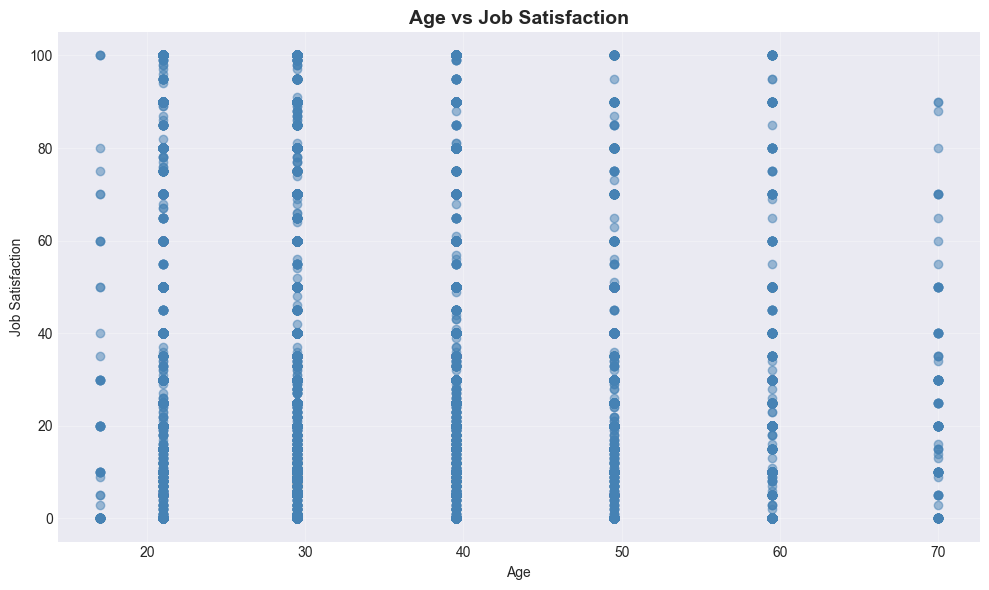

Number of data points: 29399


In [3]:
# Map age to numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

df['Age_Numeric'] = df['Age'].map(age_mapping)

# Find job satisfaction column
jobsat_col = None
for col in ['JobSatPoints_6', 'JobSat']:
    if col in df.columns:
        jobsat_col = col
        break

# Prepare data
age_jobsat = df[['Age_Numeric', jobsat_col]].dropna()
age_jobsat[jobsat_col] = pd.to_numeric(age_jobsat[jobsat_col], errors='coerce')
age_jobsat = age_jobsat.dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(age_jobsat['Age_Numeric'], age_jobsat[jobsat_col], alpha=0.5, color='steelblue')
plt.title('Age vs Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of data points: {len(age_jobsat)}")

### Scatter Plot 2: Compensation vs Job Satisfaction

I'll explore the relationship between yearly compensation and job satisfaction.

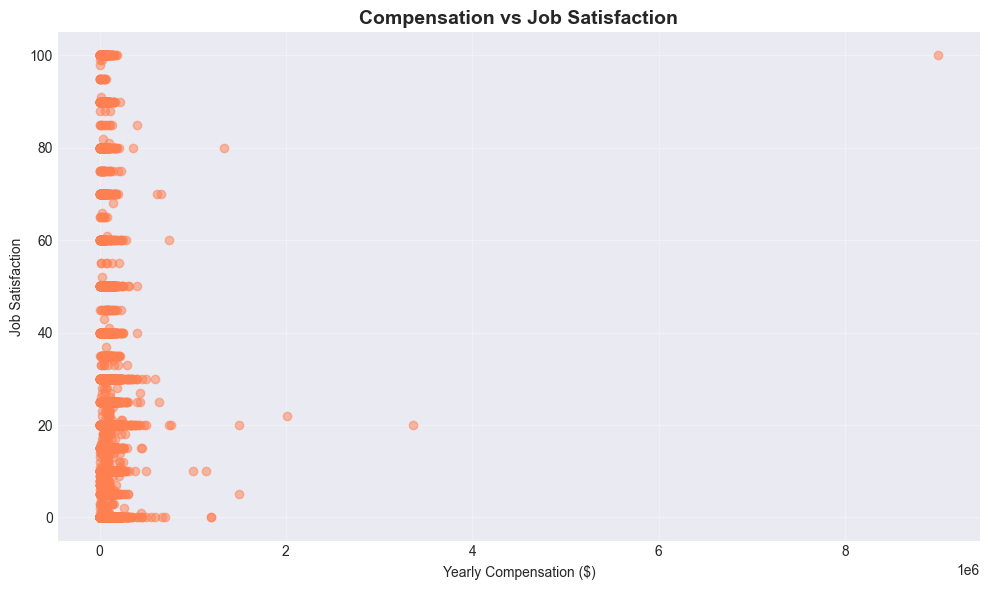

Number of data points plotted: 5000


In [4]:
# Prepare data
comp_jobsat = df[['ConvertedCompYearly', jobsat_col]].dropna()
comp_jobsat['ConvertedCompYearly'] = pd.to_numeric(comp_jobsat['ConvertedCompYearly'], errors='coerce')
comp_jobsat[jobsat_col] = pd.to_numeric(comp_jobsat[jobsat_col], errors='coerce')
comp_jobsat = comp_jobsat.dropna()

# Sample data for better visualization (if too many points)
if len(comp_jobsat) > 5000:
    comp_jobsat_sample = comp_jobsat.sample(5000, random_state=42)
else:
    comp_jobsat_sample = comp_jobsat

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(comp_jobsat_sample['ConvertedCompYearly'], comp_jobsat_sample[jobsat_col], 
           alpha=0.5, color='coral')
plt.title('Compensation vs Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Yearly Compensation ($)')
plt.ylabel('Job Satisfaction')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of data points plotted: {len(comp_jobsat_sample)}")

## Task 2: Enhancing Scatter Plots

### Scatter Plot 3: Age vs Job Satisfaction with Trend Line

I'll add a regression line to highlight trends in the data.

In [5]:
# Calculate regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(age_jobsat['Age_Numeric'], 
                                                                 age_jobsat[jobsat_col])

# Use sorted x range for a clean trend line (avoids zig-zag from unsorted DataFrame order)
x_sorted = np.sort(age_jobsat['Age_Numeric'].unique())
line_sorted = slope * x_sorted + intercept

# Create scatter plot with trend line
plt.figure(figsize=(10, 6))
plt.scatter(age_jobsat['Age_Numeric'], age_jobsat[jobsat_col], alpha=0.5, color='steelblue', label='Data')
plt.plot(x_sorted, line_sorted, color='red', linewidth=2, label=f'Trend Line (R² = {r_value**2:.3f})')
plt.title('Age vs Job Satisfaction with Trend Line', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation coefficient: {r_value:.3f}")
print(f"R-squared: {r_value**2:.3f}")

### Scatter Plot 4: Age vs Work Experience

I'll visualize the relationship between age and years of professional coding experience.

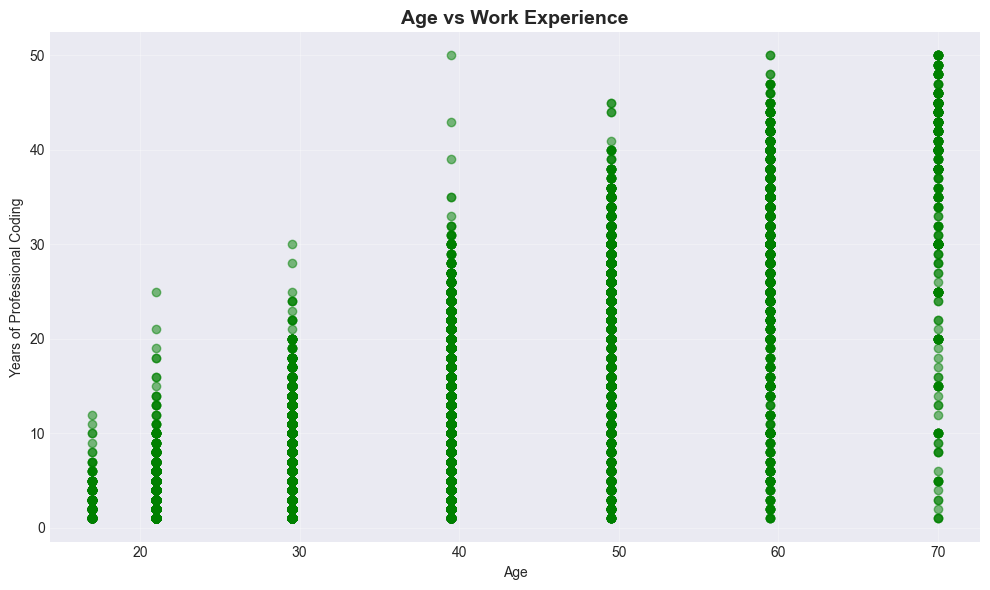

Number of data points: 48590
Correlation: 0.830


In [6]:
# Prepare data
age_exp = df[['Age_Numeric', 'YearsCodePro']].dropna()
age_exp['YearsCodePro'] = pd.to_numeric(age_exp['YearsCodePro'], errors='coerce')
age_exp = age_exp.dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(age_exp['Age_Numeric'], age_exp['YearsCodePro'], alpha=0.5, color='green')
plt.title('Age vs Work Experience', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Years of Professional Coding')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of data points: {len(age_exp)}")
print(f"Correlation: {age_exp['Age_Numeric'].corr(age_exp['YearsCodePro']):.3f}")

## Task 3: Combining Scatter Plots with Additional Features

### Scatter Plot 5 (Bubble Plot): Compensation vs Job Satisfaction with Age as Bubble Size

I'll create a bubble plot where bubble size represents age.

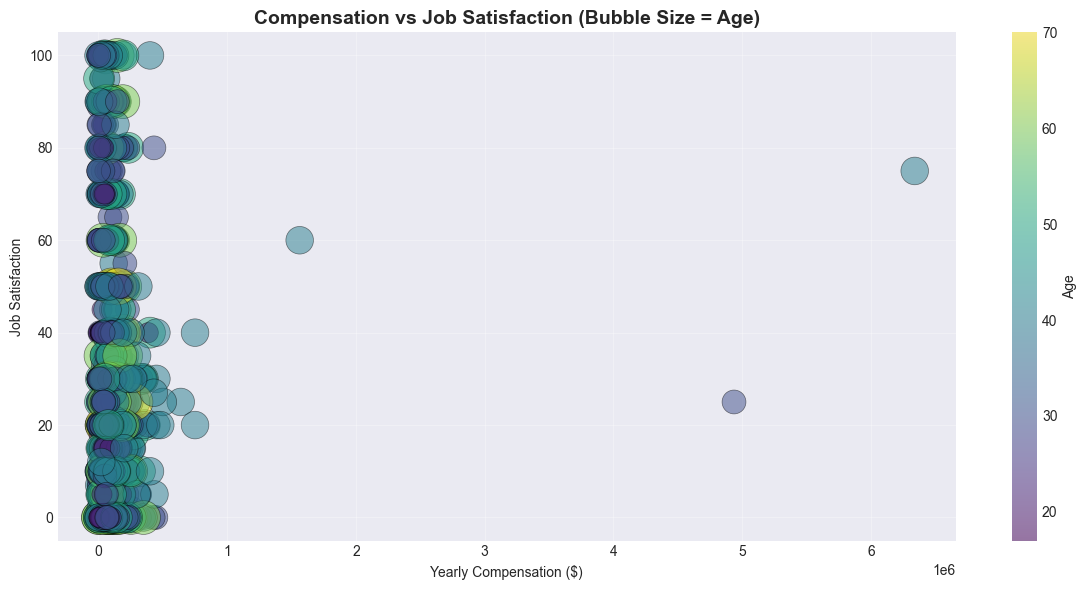

Number of bubbles plotted: 2000


In [7]:
# Prepare data
bubble_data = df[['ConvertedCompYearly', jobsat_col, 'Age_Numeric']].dropna()
bubble_data['ConvertedCompYearly'] = pd.to_numeric(bubble_data['ConvertedCompYearly'], errors='coerce')
bubble_data[jobsat_col] = pd.to_numeric(bubble_data[jobsat_col], errors='coerce')
bubble_data = bubble_data.dropna()

# Sample for better visualization
if len(bubble_data) > 2000:
    bubble_sample = bubble_data.sample(2000, random_state=42)
else:
    bubble_sample = bubble_data

# Create bubble plot
plt.figure(figsize=(12, 6))
plt.scatter(bubble_sample['ConvertedCompYearly'], bubble_sample[jobsat_col], 
           s=bubble_sample['Age_Numeric']*10, alpha=0.5, c=bubble_sample['Age_Numeric'], 
           cmap='viridis', edgecolors='black', linewidth=0.5)
plt.colorbar(label='Age')
plt.title('Compensation vs Job Satisfaction (Bubble Size = Age)', fontsize=14, fontweight='bold')
plt.xlabel('Yearly Compensation ($)')
plt.ylabel('Job Satisfaction')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of bubbles plotted: {len(bubble_sample)}")

### Scatter Plot 6: Programming Languages by Job Satisfaction

I'll visualize the top programming languages and their average job satisfaction scores.

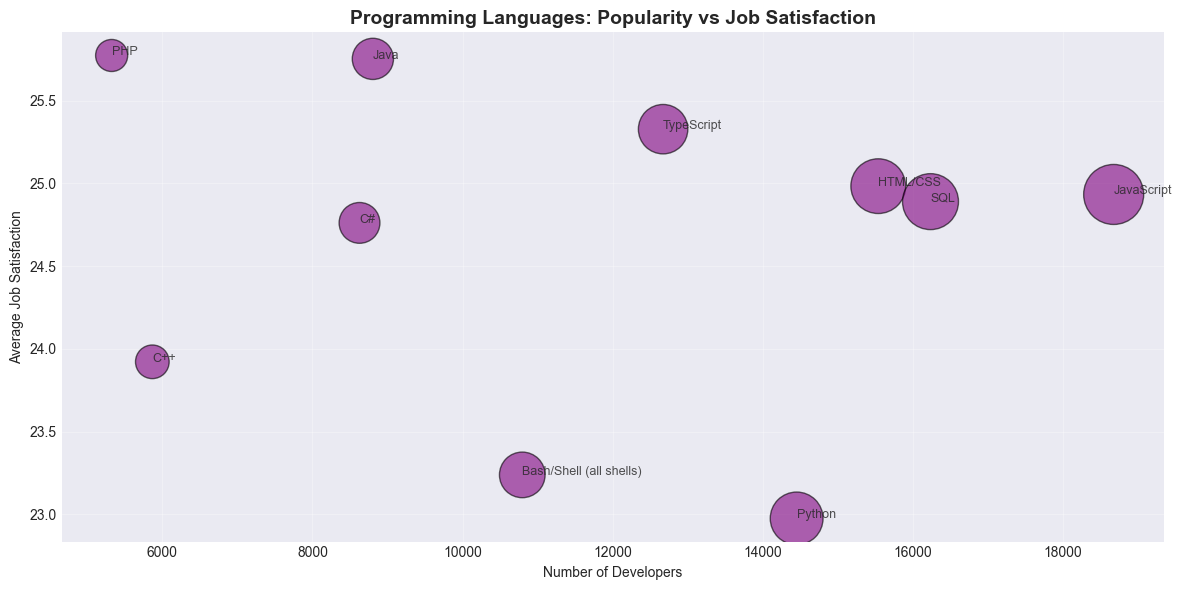

In [8]:
# Check for language column
lang_col = None
for col in ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']:
    if col in df.columns:
        lang_col = col
        break

if lang_col:
    # Prepare data
    lang_jobsat = df[[lang_col, jobsat_col]].dropna()
    lang_jobsat[jobsat_col] = pd.to_numeric(lang_jobsat[jobsat_col], errors='coerce')
    lang_jobsat = lang_jobsat.dropna()
    
    # Split languages and explode
    lang_jobsat_exploded = lang_jobsat.copy()
    lang_jobsat_exploded[lang_col] = lang_jobsat_exploded[lang_col].str.split(';')
    lang_jobsat_exploded = lang_jobsat_exploded.explode(lang_col)
    
    # Get top 10 languages
    top_langs = lang_jobsat_exploded[lang_col].value_counts().head(10).index
    
    # Calculate average satisfaction and count for each language
    lang_stats = lang_jobsat_exploded[lang_jobsat_exploded[lang_col].isin(top_langs)].groupby(lang_col).agg({
        jobsat_col: ['mean', 'count']
    }).reset_index()
    lang_stats.columns = ['Language', 'Avg_Satisfaction', 'Count']
    
    # Create scatter plot
    plt.figure(figsize=(12, 6))
    plt.scatter(lang_stats['Count'], lang_stats['Avg_Satisfaction'], 
               s=lang_stats['Count']/10, alpha=0.6, color='purple', edgecolors='black')
    
    # Add labels
    for idx, row in lang_stats.iterrows():
        plt.annotate(row['Language'], (row['Count'], row['Avg_Satisfaction']), 
                    fontsize=9, alpha=0.8)
    
    plt.title('Programming Languages: Popularity vs Job Satisfaction', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Developers')
    plt.ylabel('Average Job Satisfaction')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Language column not found")

## Task 4: Scatter Plot Comparisons Across Groups

### Scatter Plot 7: Compensation vs Job Satisfaction by Employment Type

I'll visualize the relationship categorized by employment type.

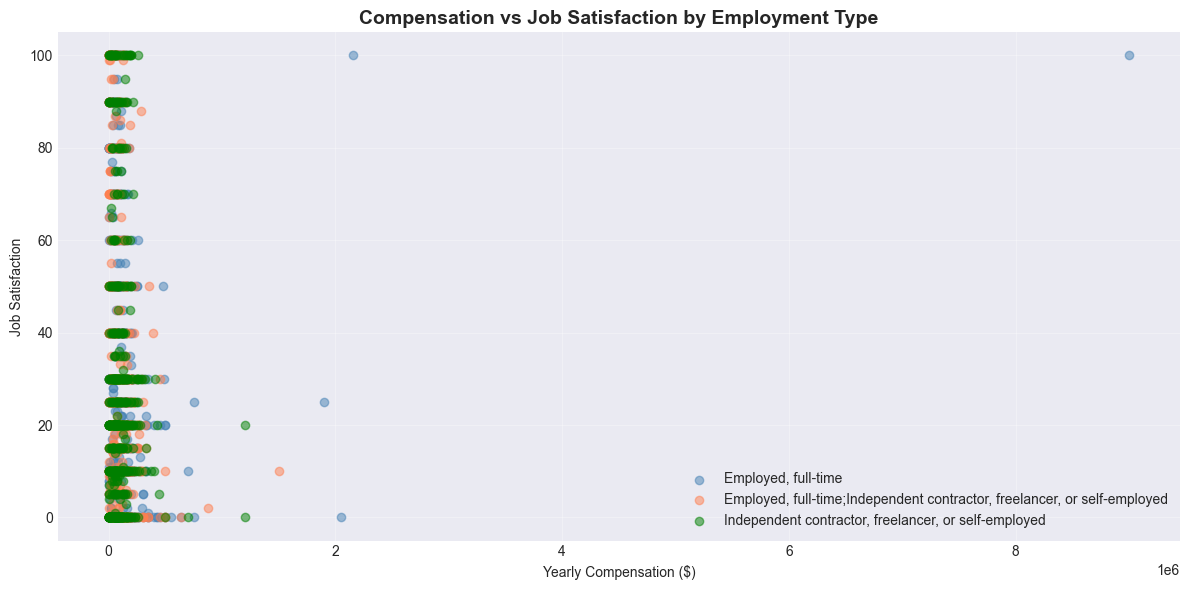

In [9]:
# Prepare data
emp_comp_jobsat = df[['Employment', 'ConvertedCompYearly', jobsat_col]].dropna()
emp_comp_jobsat['ConvertedCompYearly'] = pd.to_numeric(emp_comp_jobsat['ConvertedCompYearly'], errors='coerce')
emp_comp_jobsat[jobsat_col] = pd.to_numeric(emp_comp_jobsat[jobsat_col], errors='coerce')
emp_comp_jobsat = emp_comp_jobsat.dropna()

# Get top 3 employment types
top_emp = emp_comp_jobsat['Employment'].value_counts().head(3).index
emp_filtered = emp_comp_jobsat[emp_comp_jobsat['Employment'].isin(top_emp)]

# Sample for better visualization
if len(emp_filtered) > 3000:
    samples = []
    for emp_type in top_emp:
        group = emp_filtered[emp_filtered['Employment'] == emp_type]
        samples.append(group.sample(min(1000, len(group)), random_state=42))
    emp_sample = pd.concat(samples).reset_index(drop=True)
else:
    emp_sample = emp_filtered

# Create scatter plot with colors for employment types
plt.figure(figsize=(12, 6))
colors = ['steelblue', 'coral', 'green']
for idx, emp_type in enumerate(top_emp):
    subset = emp_sample[emp_sample['Employment'] == emp_type]
    plt.scatter(subset['ConvertedCompYearly'], subset[jobsat_col], 
               alpha=0.5, color=colors[idx], label=emp_type)

plt.title('Compensation vs Job Satisfaction by Employment Type', fontsize=14, fontweight='bold')
plt.xlabel('Yearly Compensation ($)')
plt.ylabel('Job Satisfaction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scatter Plot 8: Work Experience vs Age by Country

I'll compare work experience across age groups for different countries.

In [10]:
# Prepare data
country_age_exp = df[['Country', 'Age_Numeric', 'YearsCodePro']].dropna()
country_age_exp['YearsCodePro'] = pd.to_numeric(country_age_exp['YearsCodePro'], errors='coerce')
country_age_exp = country_age_exp.dropna()

# Get top 5 countries
top_countries = country_age_exp['Country'].value_counts().head(5).index
country_filtered = country_age_exp[country_age_exp['Country'].isin(top_countries)]

# Sample for better visualization
if len(country_filtered) > 2000:
    samples = []
    for country in top_countries:
        group = country_filtered[country_filtered['Country'] == country]
        samples.append(group.sample(min(400, len(group)), random_state=42))
    country_sample = pd.concat(samples).reset_index(drop=True)
else:
    country_sample = country_filtered

# Create scatter plot with colors for countries
plt.figure(figsize=(14, 6))
colors_map = {'United States of America': 'steelblue', 'India': 'coral', 'Germany': 'green', 
              'United Kingdom of Great Britain and Northern Ireland': 'purple', 'Canada': 'orange', 'Ukraine': 'teal'}

for country in top_countries:
    subset = country_sample[country_sample['Country'] == country]
    color = colors_map.get(country, 'gray')
    plt.scatter(subset['Age_Numeric'], subset['YearsCodePro'], 
               alpha=0.6, color=color, label=country, s=50)

plt.title('Work Experience vs Age by Country', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Years of Professional Coding')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of data points plotted: {len(country_sample)}")

## Summary

In this notebook, I created various scatter plots to analyze relationships in the developer survey data:

- **Basic scatter plots** - Age vs satisfaction, compensation vs satisfaction
- **Enhanced scatter plots** - Added trend lines to identify patterns
- **Bubble plots** - Used bubble size to represent a third variable (age)
- **Multi-dimensional comparisons** - Color-coded by employment type and country
- **Programming language analysis** - Popularity vs satisfaction

Scatter plots are powerful for:
- Identifying correlations between variables
- Spotting trends and patterns
- Detecting outliers and clusters
- Comparing relationships across groups

These visualizations revealed insights about compensation patterns, job satisfaction trends, and the relationship between age and experience across the developer community.